In [1]:
from omegaconf import OmegaConf
import os
from agents.estimator import MLEEstimator, NCEEstimator, SupervisedEstimator, SupervisedLearnableRandomFeatureEstimator
from envs.noisy_pendulum import ParallelNoisyPendulum
from envs.mvn import *
import torch
import numpy as np
exp_dir = '/home/haitong/PycharmProjects/low_rank_learning/log/mvn_contrastive_unifrom/nce/2025-03-14_16-23-54_s0_default'

In [2]:
args = OmegaConf.load(os.path.join(exp_dir, '.hydra', 'config.yaml'))
args.dynamics

'mvn_contrastive_unifrom'

In [3]:
import numpy as np
import matplotlib.pyplot as plt

def cosine_similarity_matrix(features):
    """
    Compute the cosine similarity matrix for a batch of feature vectors.
    
    Args:
        features (np.ndarray): A 2D numpy array of shape (batch_size, feature_dim)
        
    Returns:
        np.ndarray: Cosine similarity matrix of shape (batch_size, batch_size)
    """
    # Normalize each feature vector
    norms = np.linalg.norm(features, axis=1, keepdims=True)
    normalized_features = features / (norms + 1e-8)  # Avoid division by zero

    # Compute cosine similarity matrix
    similarity_matrix = np.dot(normalized_features, normalized_features.T)
    
    return similarity_matrix

def plot_similarity_matrix(similarity_matrix):
    """
    Plot the cosine similarity matrix.
    
    Args:
        similarity_matrix (np.ndarray): A square matrix of cosine similarities
    """
    plt.figure(figsize=(8, 6))
    plt.imshow(similarity_matrix, cmap='coolwarm', interpolation='nearest')
    plt.colorbar(label="Cosine Similarity")
    plt.title("Cosine Similarity Matrix")
    plt.xlabel("Feature Index")
    plt.ylabel("Feature Index")
    plt.show()



In [4]:
if args.dynamics == 'NoisyPendulum':
    data_generator = ParallelNoisyPendulum(
        # sigma=args.sigma,
        rollout_batch_size=args.train_batch_size,
        # sin_cos_obs=args.sin_cos_obs,
        prob=args.prob_labels,
        **vars(args))
    dataset, prob = data_generator.sample(batches=args.train_batches, store_path='./datasets', dist=args.sample)
elif args.dynamics == 'mvn_contrastive_normal':
    data_generator = MVNContrasiveNormal(rollout_batch_size=args.train_batch_size, )
    dataset, prob = data_generator.sample(batches=args.train_batches, store_path='./datasets')
elif args.dynamics == 'mvn_uniform_contrastive_normal':
    data_generator = MVNUniformContrastiveNormal(rollout_batch_size=args.train_batch_size, )
elif args.dynamics == 'mvn_contrastive_unifrom':
    data_generator = MVNContrastiveUnifrom(rollout_batch_size=args.train_batch_size, )
elif args.dynamics == 'mvn_uniform':
    data_generator = MVNUniform(rollout_batch_size=args.train_batch_size, )
    dataset, prob = data_generator.sample(batches=args.train_batches, store_path='./datasets')

In [5]:
args.estimator.dynamics = args.dynamics
args.estimator.device = args.device
estimator = NCEEstimator(embedding_dim=args.feature_dim,
                                 state_dim=data_generator.state_dim,
                                 action_dim=data_generator.action_dim,
                                 noise_args={},
                                 **args.estimator)
estimator.load(exp_dir)

In [6]:
trans = np.load(os.path.join('/home/haitong/PycharmProjects/low_rank_learning/datasets', 'tran_mvn_uniform.npy'))[:256]
inputs = torch.from_numpy(trans).to(torch.float32)
prob = np.load(os.path.join('/home/haitong/PycharmProjects/low_rank_learning/datasets', 'prob_mvn_uniform.npy'))[:256]

In [7]:
estimator.get_prob(inputs.to(torch.device('cuda')))

tensor([1.0744, 1.0539, 1.0004, 1.1092, 1.0464, 1.1006, 1.0385, 0.9152, 1.0807,
        1.0256, 1.0760, 1.0320, 1.0846, 1.0775, 1.0337, 1.0873, 1.0585, 1.0948,
        0.9882, 1.0400, 1.0239, 1.0836, 0.9447, 1.0913, 1.0258, 1.0455, 1.0595,
        1.0933, 1.0849, 0.9414, 1.0270, 0.8797, 1.0456, 1.1086, 1.0619, 1.1020,
        1.0520, 1.0708, 1.0926, 1.0673, 1.0990, 0.8698, 0.9385, 1.0243, 1.0699,
        1.0007, 1.0753, 1.0614, 1.0890, 1.0550, 1.0519, 1.0829, 1.0261, 1.0900,
        1.0899, 1.0407, 1.0080, 0.9004, 1.0967, 1.0607, 1.0798, 1.0247, 1.0587,
        1.0698, 0.7902, 0.9898, 1.0954, 0.9215, 1.0504, 1.0322, 1.0179, 1.0820,
        1.1020, 1.1033, 0.9627, 1.0770, 1.0825, 1.0744, 1.0952, 0.9660, 1.0765,
        1.1028, 0.9162, 1.0144, 1.0145, 1.0299, 1.0993, 0.9812, 1.0536, 1.0597,
        1.0679, 1.0509, 1.0710, 0.9545, 1.0140, 0.9805, 1.1046, 1.0470, 1.0702,
        0.9714, 1.0078, 1.0386, 1.0648, 1.0852, 1.0268, 1.0740, 1.0275, 1.1027,
        0.9284, 0.8135, 1.0437, 1.0064, 

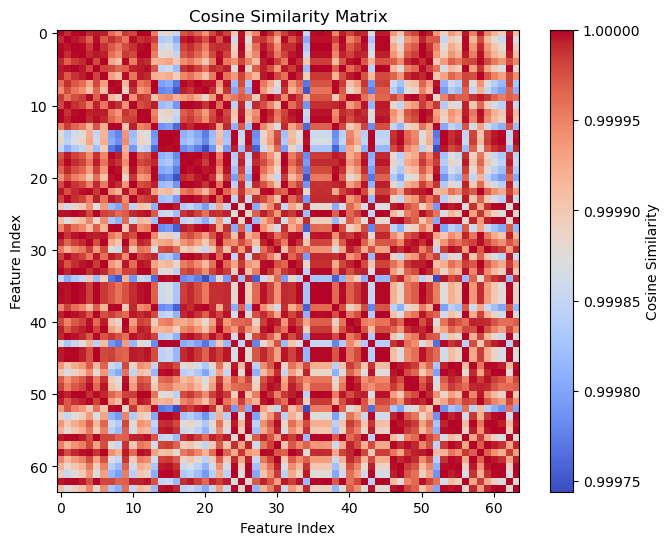

In [8]:
features = estimator.phi(inputs[:64, :1].to(torch.device('cuda'))).detach().cpu().numpy()
similarity_matrix = cosine_similarity_matrix(features)
plot_similarity_matrix(similarity_matrix)

## True prob

In [12]:
prob * 8

array([3.20399867, 3.37041731, 1.46205391, 3.68211395, 2.76532985,
       3.68065173, 2.46373831, 1.5574577 , 2.54830202, 2.46033014,
       3.67503435, 2.06323026, 3.36751332, 2.6114965 , 1.36157313,
       2.70634825, 3.67919019, 3.41377478, 2.36713666, 3.39481365,
       3.25540257, 3.68400704, 0.88628539, 3.66203772, 3.19814607,
       2.99305885, 2.20876048, 2.9680176 , 3.30240728, 0.81685482,
       2.94887548, 0.89575681, 2.56226781, 3.68429971, 3.68504203,
       3.68502729, 2.59475421, 3.09440398, 2.94886059, 3.49345695,
       3.48993271, 0.30941556, 1.43984953, 3.23611643, 3.49584077,
       2.24167176, 3.68354576, 3.67634507, 3.68037282, 2.53010213,
       2.57157921, 3.49493139, 3.29923417, 3.51080166, 3.58100718,
       3.44170708, 2.29660309, 0.37819218, 3.39314516, 3.61714639,
       2.76979235, 3.18678332, 2.78243443, 3.68328802, 0.13119439,
       1.89372033, 3.46878822, 1.47478666, 2.16229067, 3.35003063,
       0.95568833, 3.39361896, 3.19340252, 3.68408184, 1.89320

In [27]:
inputs2 = torch.concat([torch.zeros([256, 1]), torch.linspace(-1., 1., 256).unsqueeze(1)], dim=1)
estimator.get_prob(inputs2.to(torch.device('cuda')))

tensor([0.9981, 0.9981, 0.9980, 0.9980, 0.9980, 0.9980, 0.9979, 0.9979, 0.9979,
        0.9979, 0.9979, 0.9979, 0.9979, 0.9979, 0.9979, 0.9979, 0.9979, 0.9979,
        0.9979, 0.9979, 0.9980, 0.9980, 0.9980, 0.9980, 0.9980, 0.9981, 0.9981,
        0.9982, 0.9982, 0.9982, 0.9983, 0.9983, 0.9984, 0.9984, 0.9985, 0.9985,
        0.9985, 0.9986, 0.9986, 0.9987, 0.9987, 0.9988, 0.9988, 0.9989, 0.9990,
        0.9991, 0.9991, 0.9992, 0.9993, 0.9994, 0.9995, 0.9995, 0.9996, 0.9997,
        0.9998, 0.9999, 1.0000, 1.0001, 1.0002, 1.0003, 1.0005, 1.0006, 1.0008,
        1.0009, 1.0011, 1.0012, 1.0014, 1.0015, 1.0017, 1.0018, 1.0020, 1.0021,
        1.0023, 1.0025, 1.0026, 1.0028, 1.0030, 1.0032, 1.0033, 1.0035, 1.0037,
        1.0039, 1.0042, 1.0044, 1.0046, 1.0049, 1.0051, 1.0054, 1.0056, 1.0059,
        1.0063, 1.0066, 1.0069, 1.0073, 1.0076, 1.0080, 1.0084, 1.0087, 1.0091,
        1.0091, 1.0090, 1.0090, 1.0089, 1.0089, 1.0088, 1.0088, 1.0088, 1.0088,
        1.0087, 1.0087, 1.0087, 1.0086, 